In [9]:
import pandas as pd 
import numpy as np 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
from importlib import reload 

import functions.draw_forecast_cones as cones
import functions.funcs as funcs
import functions.output_functions as output 
reload(cones)
reload(output)


<module 'functions.output_functions' from 'C:\\FATE\\Code\\functions\\output_functions.py'>

In [3]:
## load data to be plotted 
fc0 = pd.read_csv('saved_output/Final/cmems_bias_pers_meanremoved_2026.csv')
dFADs = gpd.read_parquet('../Data/SAT_MI_FAD_cleanedspeeds_2026-01-01_mapped_all.parquet')
qdata = xr.load_dataset('../Data/regression_quantiles_leadtimes_cmems_bias_pers_2026.nc')

fc0.Time = pd.to_datetime(fc0.Time)

merged = output.merged_dataframe_add_all_columns(fc0, dFADs)

#### Making Forecast cone plot for the paper

7.2798 0.17652706467419776
6.3245 0.7132689539985434


(<Figure size 4000x2000 with 2 Axes>,
 <Axes: title={'center': '3 day Forecasts of dFAD \n2024-12-16 02:33:00'}>)

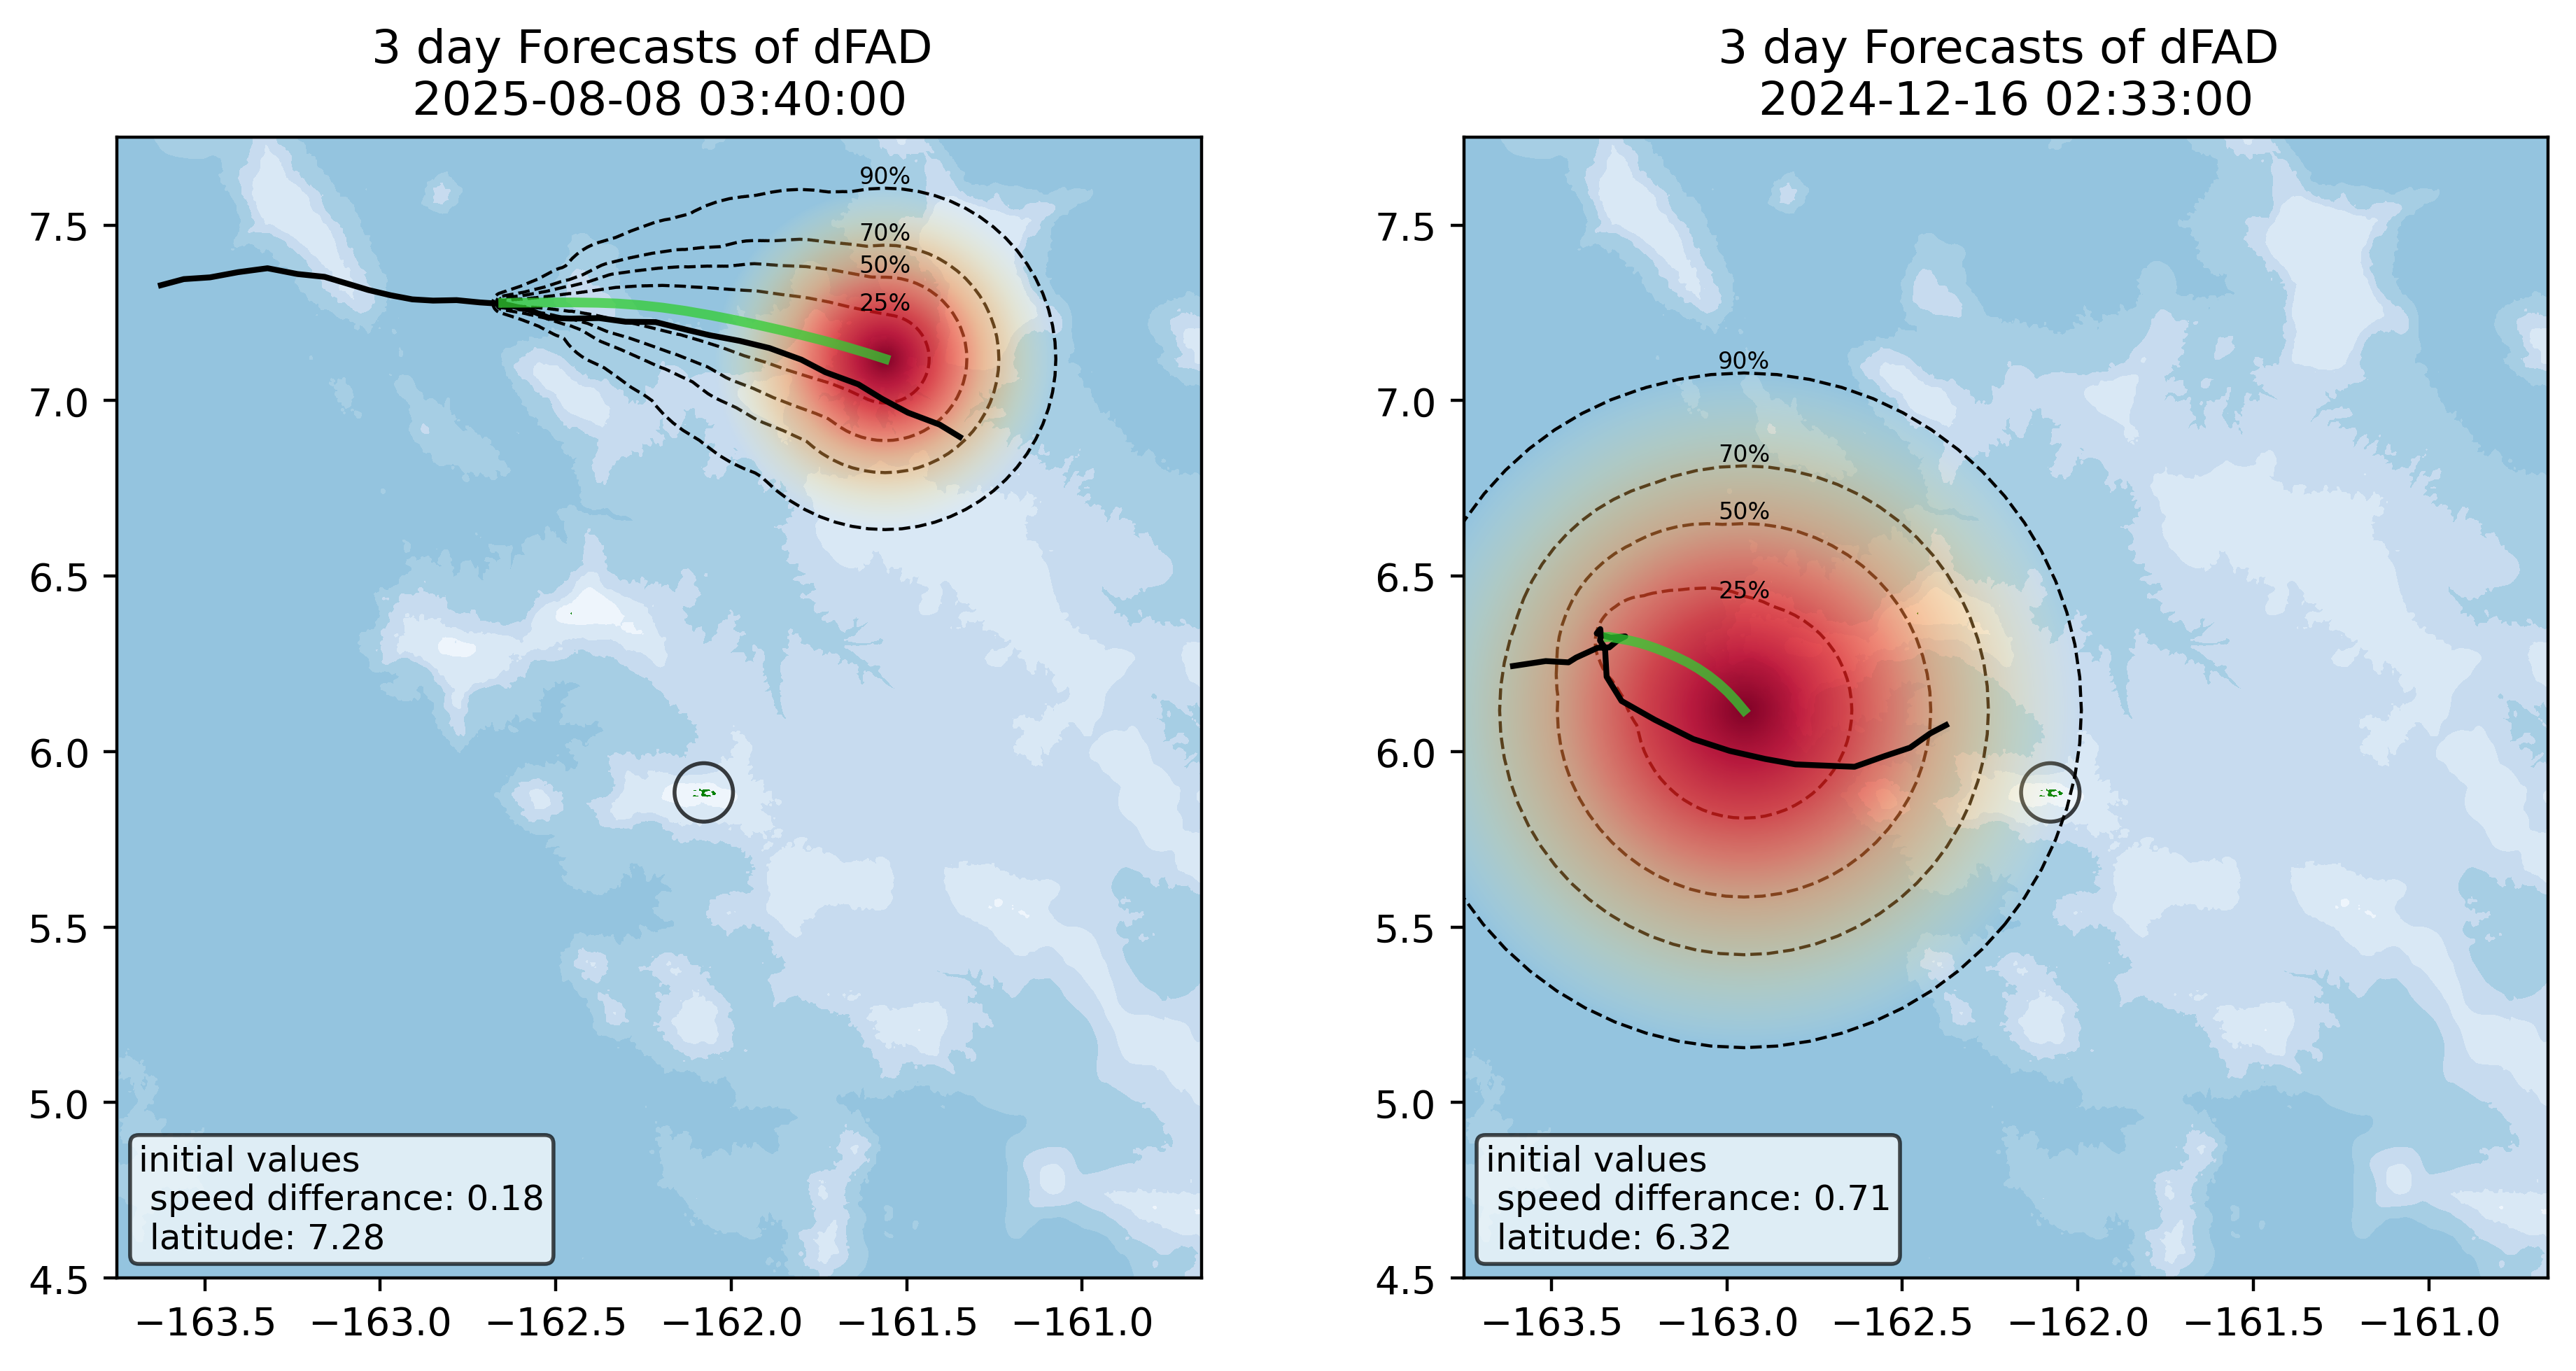

In [11]:
fig , axs = plt.subplots(1,2, figsize = (10,5), dpi = 400)
ax0 , ax1 = axs.flatten()
cones.plot_Forecast_from_dFAD_index([merged], dFADs, qdata, 255, 2, fig, ax0)
cones.plot_Forecast_from_dFAD_index([merged], dFADs, qdata, 278, 1, fig, ax1)

### Interactive pannel to select cones and forecast. 

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

# Mutable state containers
_state = {"dFAD_idx": 220, "startday": 1}

# Labels showing current values
idx_label = widgets.Label(value=f"dFAD index: {_state['dFAD_idx']}")
sd_label  = widgets.Label(value=f"Start day:  {_state['startday']}")

# Output area for the plot
out = widgets.Output()

def replot():
    out.clear_output(wait=True)
    with out:
        fig, ax = plt.subplots()
        try:
            cones.plot_Forecast_from_dFAD_index(
                [merged], dFADs, qdata,
                _state["dFAD_idx"], _state["startday"],
                fig, ax
            )
            plt.show()
        except Exception as e:
            print(f"Error: {e}")

def on_idx_up(b):
    _state["dFAD_idx"] += 1
    idx_label.value = f"dFAD index: {_state['dFAD_idx']}"
    replot()

def on_idx_down(b):
    _state["dFAD_idx"] = max(0, _state["dFAD_idx"] - 1)
    idx_label.value = f"dFAD index: {_state['dFAD_idx']}"
    replot()

def on_sd_up(b):
    _state["startday"] += 1
    sd_label.value = f"Start day:  {_state['startday']}"
    replot()

def on_sd_down(b):
    _state["startday"] = max(0, _state["startday"] - 1)
    sd_label.value = f"Start day:  {_state['startday']}"
    replot()

btn_idx_down = widgets.Button(description="dFAD  −", button_style="info",  layout=widgets.Layout(width="100px"))
btn_idx_up   = widgets.Button(description="dFAD  +", button_style="info",  layout=widgets.Layout(width="100px"))
btn_sd_down  = widgets.Button(description="Day   −", button_style="warning", layout=widgets.Layout(width="100px"))
btn_sd_up    = widgets.Button(description="Day   +", button_style="warning", layout=widgets.Layout(width="100px"))

btn_idx_down.on_click(on_idx_down)
btn_idx_up.on_click(on_idx_up)
btn_sd_down.on_click(on_sd_down)
btn_sd_up.on_click(on_sd_up)

controls = widgets.HBox([
    btn_idx_down, idx_label, btn_idx_up,
    widgets.Label("      "),
    btn_sd_down, sd_label, btn_sd_up,
])

display(controls, out)
replot()


In [ ]:
## creating annimation of forecast cones 
fig, ax = plt.subplots(figsize=(6,6))

def update(hours):
    ax.clear()  # remove previous frame drawings
    # draw forecasts for this many days
    cones.plot_Forcasts(
        buoyID, dFADs, [merged], startday=sd,
        labels=["Forecast"],
        fig=fig, ax=ax,q= qs,
        forcastlength=pd.Timedelta(hours=hours),
        pastTrajectory=pd.Timedelta(days=7), shaded_cone= True
    )
    try:
        ax.legend( loc="upper right", bbox_to_anchor=(1,0.98), bbox_transform=ax.transAxes)
    except Exception:
        pass
    Add_bathymetry(fig, ax, cbar = False)
    ax.set_aspect("equal")
    ax.text(0.75, 0.82, f"Days:{hours/24 :.2f}", bbox=dict(facecolor='white', alpha=0.5), transform=ax.transAxes)
    plot_circle_km(ax, radius_km=0.0833)
    startzoom = 2*24
    endzoom = 3.5*24
    xlim_s = np.array([-163.25+0.25, -161.75+0.25])
    ylim_s = np.array([ 5,6.5])
    xlim_e = np.array([-163.25+0.25, -160.75+0.25])
    ylim_e = np.array([ 4.5,7])
    dxlim = xlim_e - xlim_s
    dylim = ylim_e - ylim_s
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    if hours < 2*24: 
        ax.set(xlim = xlim_s, ylim =ylim_s)
    elif hours < endzoom: 
        ratio = (hours -startzoom)/(endzoom- startzoom)
        ax.set(xlim = xlim_s + dxlim*ratio, ylim = ylim_s + dylim*ratio)
    else:
        ax.set(xlim = xlim_e, ylim = ylim_e)

ani = animation.FuncAnimation(fig, update, frames=leadtimes, interval=100, blit=False)
ani.save(r"..\..\Figures\Animations\Forecast_cone.mp4", writer= 'ffmpeg')